# Gluco-X Nudge Effectiveness Analysis
### Data Science Challenge — Fatigue Analysis (Task 2)

**Goal:** Investigate whether patients develop "Nudge Fatigue" — ignoring notifications after receiving too many.

This notebook uses the `NudgeResponsePipeline` from `glucox_pipeline.py` to handle parsing and attribution (Task 1), then focuses on the analysis and visualization.

**AI Disclosure:** Used Claude (Anthropic) for code refactoring and header wording. All code was built from scratch or adapted from previous notebookss. All logic after refactoring was reviewed and adapted manually.

## 1. Setup & Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from glucox_pipeline import NudgeResponsePipeline

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.05)
plt.rcParams["figure.dpi"] = 130

import os
os.makedirs("charts", exist_ok=True)

## 2. Run the Pipeline

The heavy lifting (parsing JSONL, attributing measurements to nudges with the 4h window rule) is handled by the pipeline class. We just call it and grab the resulting table.

In [2]:
pipeline = NudgeResponsePipeline("/content/app_logs.jsonl", "/content/patient_registry.csv")
pipeline.parse().attribute()

df = pipeline.get_attribution_table()
print(f"Attribution table: {df.shape[0]} rows, {df.shape[1]} columns")
df.head(30)

Attribution table: 13590 rows, 10 columns


,event_id,patient_id,timestamp,nudge_type,responded,response_time_min,nudge_seq,nudge_seq_by_type,age_group,risk_segment
0,evt_0,P_0000,2023-10-02 11:00:00,Urgent_Alert,True,31.0,1,1,36-50,High
1,evt_2,P_0000,2023-10-06 08:00:00,Urgent_Alert,True,33.0,2,2,36-50,High
2,evt_4,P_0000,2023-10-07 16:00:00,Gentle_Reminder,True,142.0,3,1,36-50,High
3,evt_6,P_0000,2023-10-09 15:00:00,Gentle_Reminder,True,153.0,4,2,36-50,High
4,evt_8,P_0000,2023-10-11 19:00:00,Gentle_Reminder,True,117.0,5,3,36-50,High
5,evt_10,P_0000,2023-10-12 20:00:00,Gentle_Reminder,True,137.0,6,4,36-50,High
6,evt_12,P_0000,2023-10-13 13:00:00,Gentle_Reminder,False,NaN,7,5,36-50,High
7,evt_13,P_0000,2023-10-17 09:00:00,Urgent_Alert,True,32.0,8,3,36-50,High
8,evt_15,P_0000,2023-10-21 08:00:00,Gentle_Reminder,True,76.0,9,6,36-50,High
9,evt_17,P_0000,2023-10-26 18:00:00,Urgent_Alert,False,NaN,10,4,36-50,High


### 2.1 Quick sanity check

In [ ]:
print(f"Overall response rate: {df['responded'].mean():.1%}")
print(f"Total nudges: {len(df)}, Responded: {df['responded'].sum()}")
print()
print("By nudge type:")
print(df.groupby("nudge_type")["responded"].agg(["mean", "count"]))
print()
print("Columns available:")
print(df.columns.tolist())

Overall response rate: 41.1%
Total nudges: 13590, Responded: 5582

By nudge type:
                     mean  count
nudge_type                      
Gentle_Reminder  0.423885   6707
Urgent_Alert     0.397937   6883

Columns available:
['event_id', 'patient_id', 'timestamp', 'nudge_type', 'responded', 'response_time_min', 'nudge_seq', 'nudge_seq_by_type', 'age_group', 'risk_segment']


## 3. Fatigue Analysis

Question: **does response rate drop as patients receive more nudges?**

Bucket the `nudge_seq` column and look at response rates per bucket.

### Chart 1 — Overall Fatigue Curve

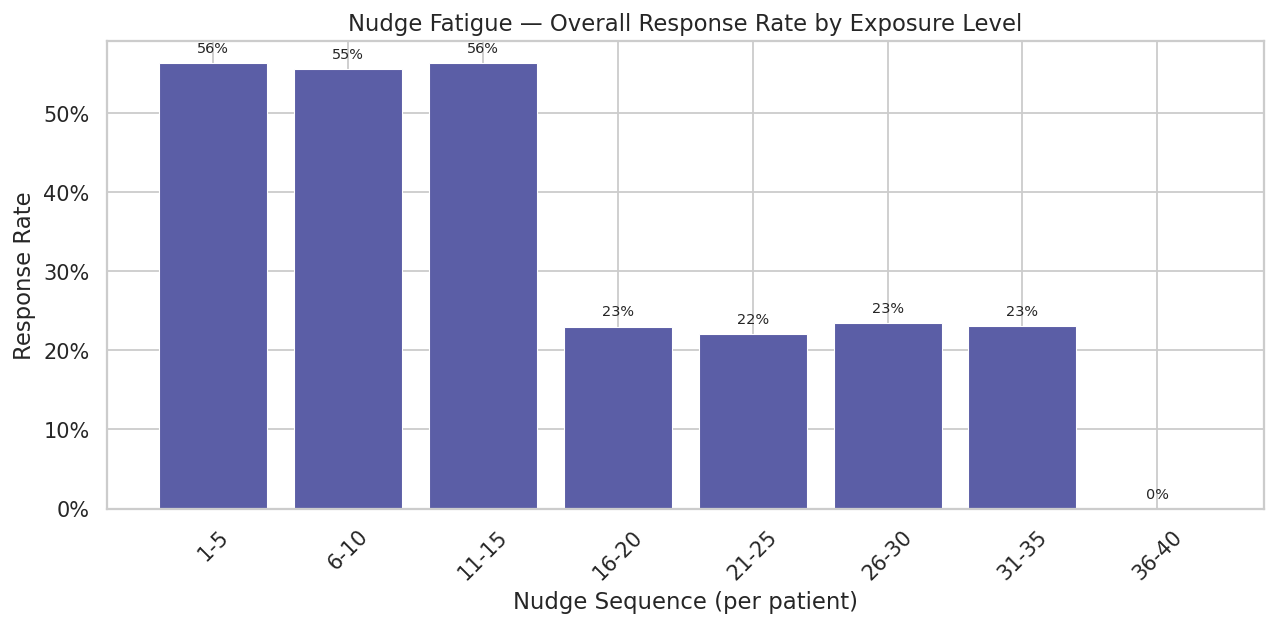

bucket  response_rate  n_nudges
   1-5       0.562400      2500
  6-10       0.554800      2500
 11-15       0.562400      2500
 16-20       0.229936      2492
 21-25       0.220848      2264
 26-30       0.234079      1162
 31-35       0.230303       165
 36-40       0.000000         7


In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))
bins = list(range(0, 51, 5))
labels = [f"{b+1}-{b+5}" for b in bins[:-1]]

df["seq_bucket"] = pd.cut(df["nudge_seq"], bins=bins, labels=labels, right=True)

fatigue = (
    df.groupby("seq_bucket", observed=False)["responded"]
    .agg(["mean", "count"])
    .reset_index()
)
fatigue.columns = ["bucket", "response_rate", "n_nudges"]
fatigue = fatigue[fatigue["n_nudges"] > 0]

#bar plot

bars = ax.bar(
    fatigue["bucket"],
    fatigue["response_rate"],
    color="#5B5EA6",
    edgecolor="white",
    linewidth=0.6,
)

for bar, rate, n in zip(bars, fatigue["response_rate"], fatigue["n_nudges"]):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.01,
        f"{rate:.0%}",
        ha="center", va="bottom", fontsize=8,
    )

ax.set_xlabel("Nudge Sequence (per patient)")
ax.set_ylabel("Response Rate")
ax.set_title("Nudge Fatigue — Overall Response Rate by Exposure Level")
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.savefig("charts/chart1_fatigue_overall.png")
plt.show()

# print table
print(fatigue.to_string(index=False))

**Observation:** There's a clear cliff between the 11-15 and 16-20 buckets. Response rate drops from ~56% to ~23%. The Product manager intuition about fatigue is accurate.

### Chart 2 — Fatigue by Nudge Type

Do Urgent Alerts hold up better than Gentle Reminders over time, or do they decay the same way?

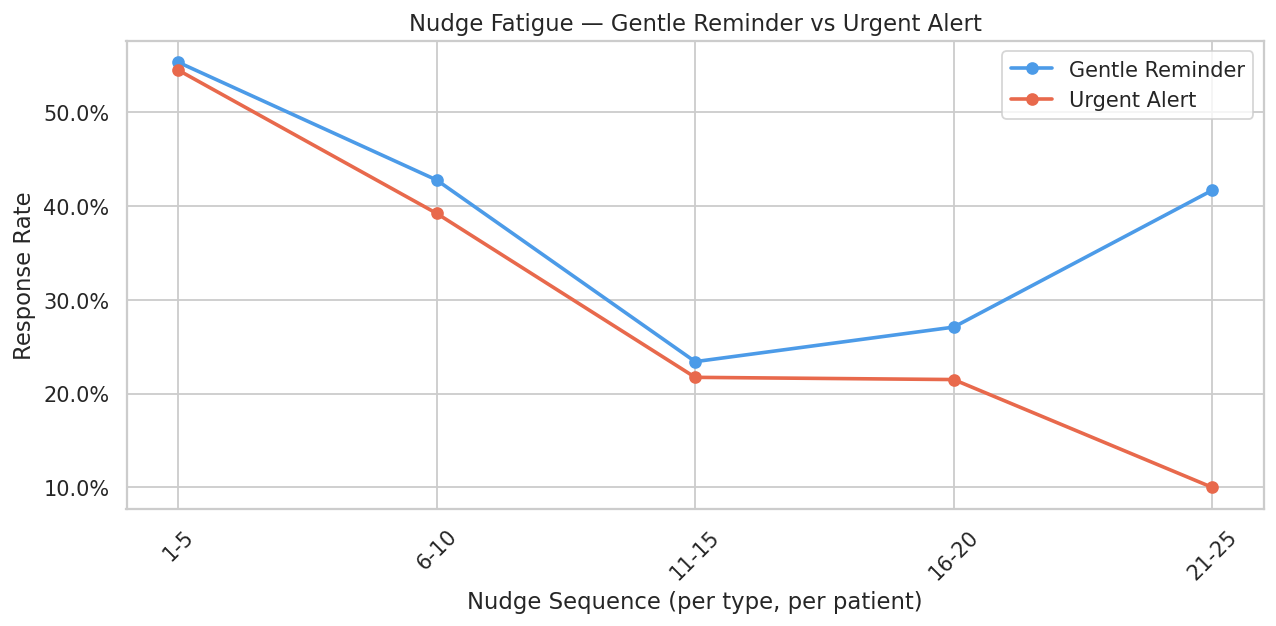

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))

colors_map = {"Gentle_Reminder": "#4C9BE8", "Urgent_Alert": "#E8694C"}

for ntype in ["Gentle_Reminder", "Urgent_Alert"]:
    sub = df[df["nudge_type"] == ntype].copy()
    sub["seq_type_bucket"] = pd.cut(
        sub["nudge_seq_by_type"], bins=bins, labels=labels, right=True
    )
    agg = (
        sub.groupby("seq_type_bucket", observed=False)["responded"]
        .agg(["mean", "count"])
        .reset_index()
    )
    agg.columns = ["bucket", "response_rate", "n"]
    #agg = agg[agg["n"] > 10]  # drop tiny buckets

    ax.plot(
        agg["bucket"],
        agg["response_rate"],
        marker="o",
        label=ntype.replace("_", " "),
        color=colors_map[ntype],
        linewidth=2,
    )

ax.set_xlabel("Nudge Sequence (per type, per patient)")
ax.set_ylabel("Response Rate")
ax.set_title("Nudge Fatigue — Gentle Reminder vs Urgent Alert")
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.legend()
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.savefig("charts/chart2_fatigue_by_type.png")
plt.show()

**Observation:** Both types follow almost the same decay curve. Urgent Alerts don't outperform Gentle Reminders at any stage. The nudge *type* isn't what matters — it's the sheer *volume*.

### Chart 3 — Heatmap (Type × Exposure Bucket)

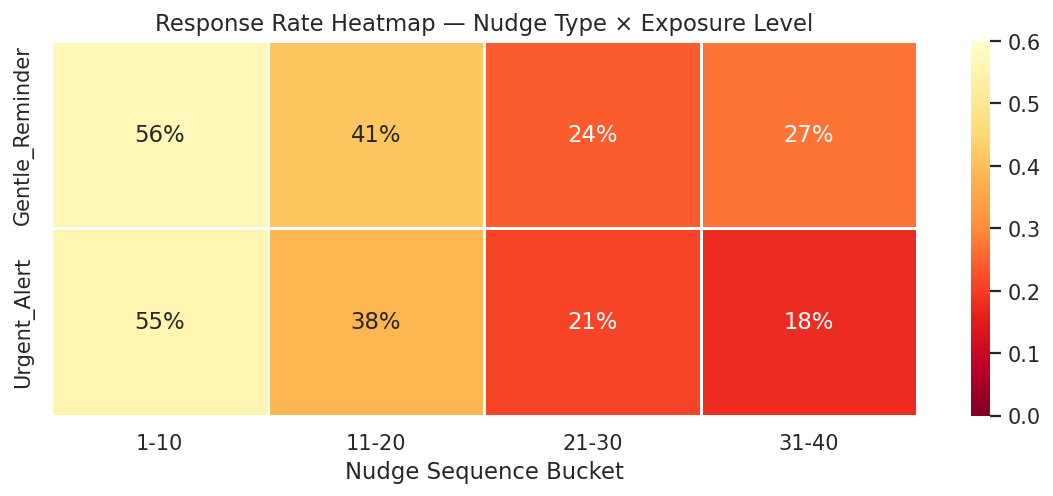

In [ ]:
bins_wide = list(range(0, 51, 10))
labels_wide = [f"{b+1}-{b+10}" for b in bins_wide[:-1]]

df["seq_bucket_wide"] = pd.cut(
    df["nudge_seq"], bins=bins_wide, labels=labels_wide, right=True
)

pivot = df.pivot_table(
    values="responded",
    index="nudge_type",
    columns="seq_bucket_wide",
    aggfunc="mean",
    observed=False,
)

fig, ax = plt.subplots(figsize=(9, 4))
sns.heatmap(
    pivot, annot=True, fmt=".0%", cmap="YlOrRd_r",
    linewidths=0.8, ax=ax, vmin=0, vmax=0.6,
)
ax.set_title("Response Rate Heatmap — Nudge Type × Exposure Level")
ax.set_ylabel("")
ax.set_xlabel("Nudge Sequence Bucket")
plt.tight_layout()
plt.savefig("charts/chart6_heatmap.png")
plt.show()

## 4. Response Time Analysis

For patients who *do* respond — does it take them longer as they get more nudges?

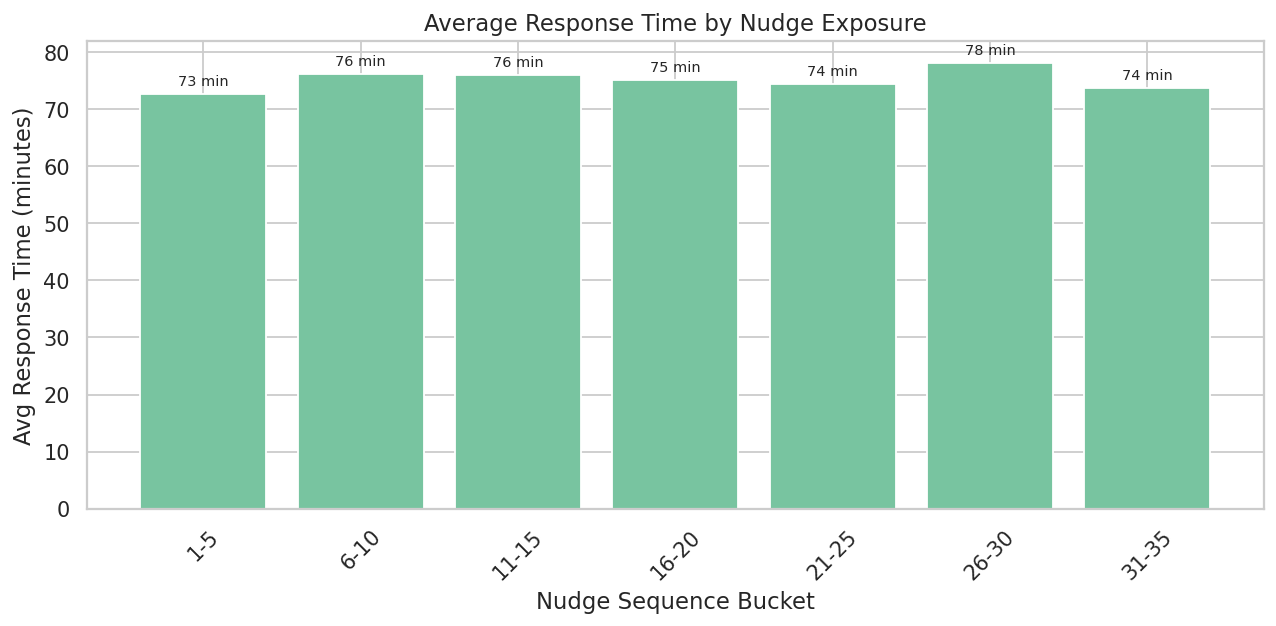

bucket  mean_min  median_min    n
   1-5 72.736131        45.0 1406
  6-10 76.276136        55.0 1387
 11-15 76.049787        56.0 1406
 16-20 75.174520        48.0  573
 21-25 74.448000        49.5  500
 26-30 78.077206        55.5  272
 31-35 73.815789        65.5   38


In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))

responded_df = df[df["responded"]].copy()
responded_df["seq_bucket"] = pd.cut(
    responded_df["nudge_seq"], bins=bins, labels=labels, right=True
)
rt_agg = (
    responded_df.groupby("seq_bucket", observed=False)["response_time_min"]
    .agg(["mean", "median", "count"])
    .reset_index()
)
rt_agg.columns = ["bucket", "mean_min", "median_min", "n"]
rt_agg = rt_agg[rt_agg["n"] > 0]

ax.bar(
    rt_agg["bucket"],
    rt_agg["mean_min"],
    color="#78C4A0",
    edgecolor="white",
)

for bar, val in zip(ax.patches, rt_agg["mean_min"]):
    if not np.isnan(val):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 1,
            f"{val:.0f} min",
            ha="center", va="bottom", fontsize=8,
        )

ax.set_xlabel("Nudge Sequence Bucket")
ax.set_ylabel("Avg Response Time (minutes)")
ax.set_title("Average Response Time by Nudge Exposure")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.savefig("charts/chart5_response_time.png")
plt.show()

#table
print(rt_agg.to_string(index=False))

**Observation:** Response time stays flat. Fatigue isn't about responding *slower* — patients just stop responding altogether. It's binary: they either act on it quickly or completely ignore it.

## 5. Demographic Breakdown

### Chart 4 — Response Rate by Risk Segment

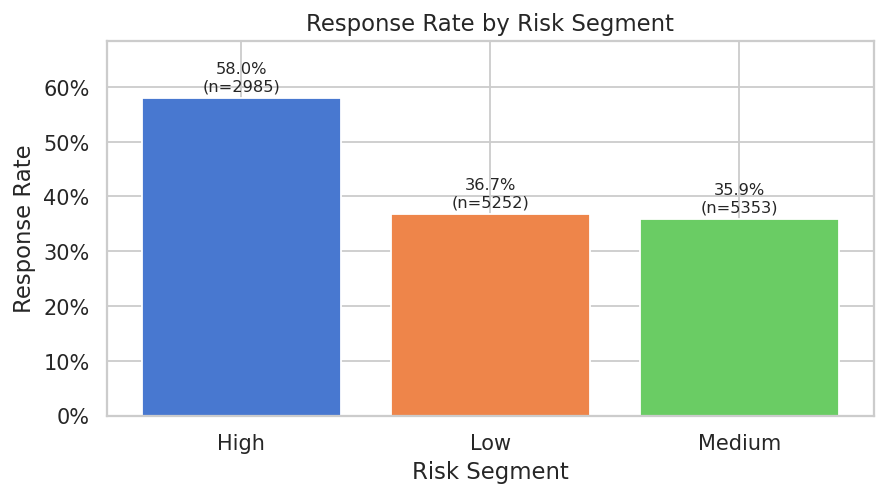

In [ ]:
seg_agg = (
    df.groupby("risk_segment")["responded"]
    .agg(["mean", "count"])
    .reset_index()
)
seg_agg.columns = ["risk_segment", "response_rate", "n"]

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(
    seg_agg["risk_segment"],
    seg_agg["response_rate"],
    color=sns.color_palette("muted", 3),
    edgecolor="white",
)

for bar, rate, n in zip(bars, seg_agg["response_rate"], seg_agg["n"]):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.008,
        f"{rate:.1%}\n(n={n})",
        ha="center", va="bottom", fontsize=9,
    )

ax.set_xlabel("Risk Segment")
ax.set_ylabel("Response Rate")
ax.set_title("Response Rate by Risk Segment")
ax.set_ylim(0, seg_agg["response_rate"].max() * 1.18)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
plt.tight_layout()
plt.savefig("charts/chart3_risk_segment.png")
plt.show()

**Observation:** High-risk patients respond way more (~58%) vs Low/Medium (~36%). Makes sense — they have more at stake. This is the most actionable demographic cut.

### Chart 5 — Response Rate by Age Group

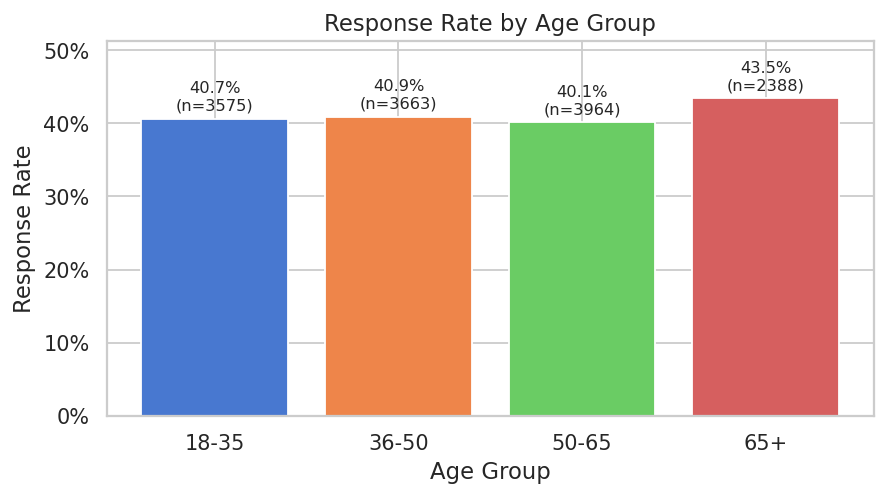

In [ ]:
age_agg = (
    df.groupby("age_group")["responded"]
    .agg(["mean", "count"])
    .reset_index()
)
age_agg.columns = ["age_group", "response_rate", "n"]

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(
    age_agg["age_group"],
    age_agg["response_rate"],
    color=sns.color_palette("muted", 4),
    edgecolor="white",
)

for bar, rate, n in zip(bars, age_agg["response_rate"], age_agg["n"]):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.008,
        f"{rate:.1%}\n(n={n})",
        ha="center", va="bottom", fontsize=9,
    )

ax.set_xlabel("Age Group")
ax.set_ylabel("Response Rate")
ax.set_title("Response Rate by Age Group")
ax.set_ylim(0, age_agg["response_rate"].max() * 1.18)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
plt.tight_layout()
plt.savefig("charts/chart4_age_group.png")
plt.show()

**Observation:** Age doesn't really move the needle, all groups sit in the 40-43% range. Wouldn't build a strategy around age alone.

## 6. Summary & Takeaways

**Fatigue is real.** Clear cliff around nudge #15-16 where response rates drop by around 33 percentage points.

**Both nudge types decay equally.** Urgent Alerts don't hold up better, switching tone alone won't fix fatigue.

**High-risk patients are the most engaged.** 58% vs ~36% for others. Worth tailoring strategy for them.

**Fatigue = disengagement, not slowness.** Response time stays flat, people either respond quickly or not at all.

**Recommendation:** Cap nudges around 12-15 per patient, introduce cooldown periods after consecutive non-responses, and experiment with fundamentally different nudge formats instead of just tone changes.